# 📊 Crypto vs Traditional Markets
## Analyzing Bitcoin and the S&P 500: Correlation, Crash Behavior, and Volatility

**Course:** Financial Technology  
**Data Sources:**  
- 🟠 Bitcoin (BTC-USD) — Yahoo Finance via `yfinance`  
- 🔵 S&P 500 Index — Federal Reserve Economic Data (FRED) via `pandas_datareader`  
**Date Range:** January 2016 – December 2025  

---

### Research Questions
1. **Is Bitcoin correlated with the stock market?**  
2. **Does Bitcoin act as a hedge during market crashes?**  
3. **How does volatility compare between crypto and equities?**


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


## 2. Data Collection

We use **two independent data sources**:

| Source | Asset | Provider | Access Method |
|--------|-------|----------|---------------|
| Yahoo Finance | Bitcoin (BTC-USD) | Markit / Yahoo | `yfinance` Python library |
| FRED (Federal Reserve) | S&P 500 Index | St. Louis Fed | `pandas_datareader` |

**Coverage:** January 1, 2016 – December 31, 2025 (daily frequency)  
The S&P 500 only trades on business days, while Bitcoin trades 24/7. We align both series using an inner join on matching dates.


In [2]:
START = '2016-01-01'
END   = '2025-12-31'

# --- Source 1: Bitcoin from Yahoo Finance ---
print("⏳ Fetching Bitcoin (BTC-USD) from Yahoo Finance...")
btc_raw = yf.download('BTC-USD', start=START, end=END, progress=False)['Close']
btc_raw = btc_raw.squeeze()   # flatten MultiIndex columns if present
btc_raw.name = 'BTC'
btc_raw.index = pd.to_datetime(btc_raw.index)

print(f"   BTC records: {len(btc_raw):,} | Range: {btc_raw.index[0].date()} → {btc_raw.index[-1].date()}")

# --- Source 2: S&P 500 from FRED ---
print("⏳ Fetching S&P 500 from FRED...")
sp_raw = pdr.DataReader('SP500', 'fred', START, END)
sp_raw.columns = ['SP500']
sp_raw.index = pd.to_datetime(sp_raw.index)

print(f"   SP500 records: {len(sp_raw):,} | Range: {sp_raw.index[0].date()} → {sp_raw.index[-1].date()}")
print("\n✅ Raw data collected from both sources.")

⏳ Fetching Bitcoin (BTC-USD) from Yahoo Finance...


   BTC records: 3,652 | Range: 2016-01-01 → 2025-12-30
⏳ Fetching S&P 500 from FRED...
   SP500 records: 2,523 | Range: 2016-05-02 → 2025-12-31

✅ Raw data collected from both sources.


## 3. Data Cleaning & Preparation

Here we apply all the required data manipulation steps:
- Handle missing values
- Merge the two datasets (inner join on date)
- Sort by date and reset index
- Data type conversion
- Generate new columns (returns, log returns, rolling stats)
- Subsets, groupby, and aggregation


In [3]:
# ── 3a. Check for missing values in raw data ──────────────────────────────────
print("=== Missing Values (Raw) ===")
print(f"BTC  NaNs: {btc_raw.isna().sum()}")
print(f"SP500 NaNs: {sp_raw['SP500'].isna().sum()}")

# FRED sometimes returns '.' for non-trading days — those become NaN
# We forward-fill SP500 to cover any gaps, then merge
sp_filled = sp_raw.ffill()

# ── 3b. Merge tables (inner join on matching dates) ───────────────────────────
prices = btc_raw.to_frame().join(sp_filled, how='inner')

# ── 3c. Drop any remaining NaNs ───────────────────────────────────────────────
prices = prices.dropna()
print(f"\nAfter inner join & dropna: {len(prices):,} rows")

# ── 3d. Sort by date (index) ──────────────────────────────────────────────────
prices = prices.sort_index()

# ── 3e. Data type conversion — ensure float64 ────────────────────────────────
prices = prices.astype({'BTC': 'float64', 'SP500': 'float64'})
print(f"\nData types:\n{prices.dtypes}")

=== Missing Values (Raw) ===
BTC  NaNs: 0
SP500 NaNs: 91

After inner join & dropna: 2,522 rows

Data types:
BTC      float64
SP500    float64
dtype: object


In [4]:
# ── 3f. Generate new columns ──────────────────────────────────────────────────

# Daily simple returns
returns = prices.pct_change().dropna()
returns.columns = ['BTC_ret', 'SP500_ret']

# Log returns (more statistically robust)
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.columns = ['BTC_log', 'SP500_log']

# Cumulative returns (base 100)
cumulative = (1 + returns).cumprod() * 100
cumulative.columns = ['BTC_cum', 'SP500_cum']

# Rolling 30-day volatility (annualised)
roll_vol = returns.rolling(30).std() * np.sqrt(252) * 100
roll_vol.columns = ['BTC_vol30', 'SP500_vol30']

# Rolling 90-day correlation
rolling_corr = returns['BTC_ret'].rolling(90).corr(returns['SP500_ret'])

# Add Year column for groupby
returns['Year'] = returns.index.year
log_returns['Year'] = log_returns.index.year

print("New columns generated ✅")
print("\nReturns DataFrame (first 5 rows):")
print(returns.head())

New columns generated ✅

Returns DataFrame (first 5 rows):
             BTC_ret  SP500_ret  Year
2016-05-03  0.012672  -0.008677  2016
2016-05-04 -0.007955  -0.005937  2016
2016-05-05  0.002807  -0.000239  2016
2016-05-06  0.025954   0.003175  2016
2016-05-09  0.001915   0.000753  2016


In [5]:
# ── 3g. Obtain subset: post-COVID period (2020-onwards) ──────────────────────
returns_post2020 = returns[returns.index >= '2020-01-01'].copy()
print(f"Post-2020 subset: {len(returns_post2020):,} rows")

# ── 3h. Full merged prices DataFrame overview ─────────────────────────────────
print("\n=== Prices DataFrame (last 5 rows) ===")
print(prices.tail())
print(f"\nShape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")

Post-2020 subset: 1,565 rows

=== Prices DataFrame (last 5 rows) ===
                     BTC    SP500
2025-12-24  87611.960938  6932.05
2025-12-25  87234.742188  6932.05
2025-12-26  87301.429688  6929.94
2025-12-29  87138.140625  6905.74
2025-12-30  88430.132812  6896.24

Shape: (2522, 2)
Date range: 2016-05-02 → 2025-12-30


## 4. Exploratory Data Analysis (EDA)

Before answering our research questions, we explore the data through descriptive statistics and visualizations.


In [6]:
# ── 4a. Descriptive Statistics ───────────────────────────────────────────────
print("=== Descriptive Statistics: Daily Prices ===")
print(prices.describe().round(2))

print("\n=== Descriptive Statistics: Daily Returns (%) ===")
desc = (returns[['BTC_ret','SP500_ret']] * 100).describe().round(4)
desc.columns = ['BTC (%)', 'SP500 (%)']
print(desc)

=== Descriptive Statistics: Daily Prices ===
             BTC    SP500
count    2522.00  2522.00
mean    31285.53  3831.69
std     32127.74  1270.42
min       438.71  2000.54
25%      6772.18  2747.84
50%     19196.36  3783.25
75%     47175.27  4538.37
max    124752.53  6932.05

=== Descriptive Statistics: Daily Returns (%) ===
         BTC (%)  SP500 (%)
count  2521.0000  2521.0000
mean      0.2975     0.0539
std       4.1723     1.1247
min     -37.1695   -11.9841
25%      -1.5171    -0.3298
50%       0.1915     0.0452
75%       2.0678     0.5600
max      25.2472     9.5154


In [7]:
# ── 4b. Annual Aggregation via groupby ────────────────────────────────────────
annual_stats = returns.groupby('Year')[['BTC_ret','SP500_ret']].agg(['mean','std','min','max'])
annual_stats.columns = ['BTC_mean','BTC_std','BTC_min','BTC_max',
                        'SP500_mean','SP500_std','SP500_min','SP500_max']
annual_stats = (annual_stats * 100).round(4)   # express as %
print("=== Annual Return Statistics (%) by Year ===")
print(annual_stats)

=== Annual Return Statistics (%) by Year ===
      BTC_mean  BTC_std  BTC_min  BTC_max  SP500_mean  SP500_std  SP500_min  \
Year                                                                          
2016    0.4923   3.1685 -10.5806  21.9762      0.0442     0.6813    -3.5920   
2017    1.2113   5.7035 -18.7411  25.2472      0.0691     0.4140    -1.8178   
2018   -0.4047   4.7906 -21.2381  13.2160     -0.0191     1.0533    -4.0979   
2019    0.3395   4.2668 -14.7026  22.5129      0.1002     0.7717    -2.9778   
2020    0.6406   4.4617 -37.1695  18.1878      0.0804     2.1313   -11.9841   
2021    0.2996   4.9109 -13.7661  21.1097      0.0946     0.8109    -2.5678   
2022   -0.3132   3.9521 -22.6807  11.6978     -0.0720     1.4962    -4.3237   
2023    0.3996   2.9156  -7.0979  19.8655      0.0867     0.8089    -2.0041   
2024    0.3647   3.4994 -12.0876  15.8808      0.0831     0.7816    -2.9969   
2025    0.0095   2.4785  -9.4656   8.2625      0.0678     1.1573    -5.9750   

      

In [8]:
# ── 4c. Annual Return (total %) per year ─────────────────────────────────────
annual_return = returns.groupby('Year')[['BTC_ret','SP500_ret']].apply(
    lambda x: (1 + x).prod() - 1
) * 100
annual_return.columns = ['BTC Annual Return (%)', 'SP500 Annual Return (%)']
print("=== Annual Total Return (%) ===")
print(annual_return.round(2))

=== Annual Total Return (%) ===
      BTC Annual Return (%)  SP500 Annual Return (%)
Year                                                
2016                 116.17                     7.56
2017                1424.72                    19.42
2018                 -74.46                    -6.24
2019                  92.20                    28.88
2020                 303.16                    16.26
2021                  59.67                    26.89
2022                 -64.15                   -19.44
2023                 153.57                    24.23
2024                 121.93                    23.31
2025                  -5.35                    17.25


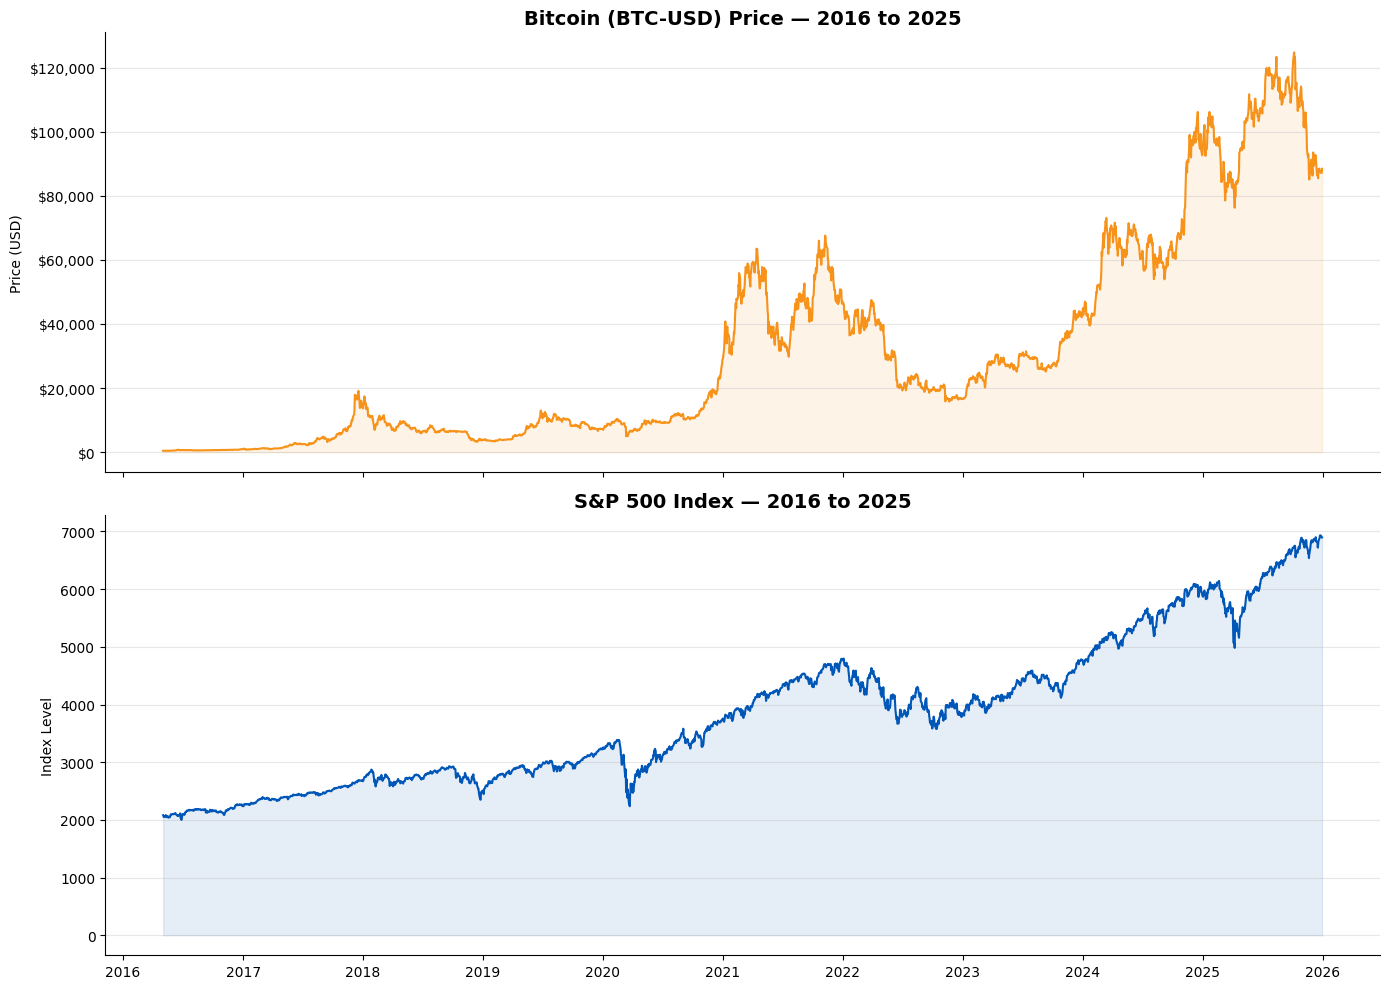

Figure 1: Price history saved ✅


In [9]:
# ── 4d. Price History Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Bitcoin price
axes[0].plot(prices.index, prices['BTC'], color='#F7931A', linewidth=1.5)
axes[0].set_title('Bitcoin (BTC-USD) Price — 2016 to 2025', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].fill_between(prices.index, prices['BTC'], alpha=0.1, color='#F7931A')

# S&P 500 price
axes[1].plot(prices.index, prices['SP500'], color='#0057B7', linewidth=1.5)
axes[1].set_title('S&P 500 Index — 2016 to 2025', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Index Level')
axes[1].fill_between(prices.index, prices['SP500'], alpha=0.1, color='#0057B7')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig1_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Price history saved ✅")

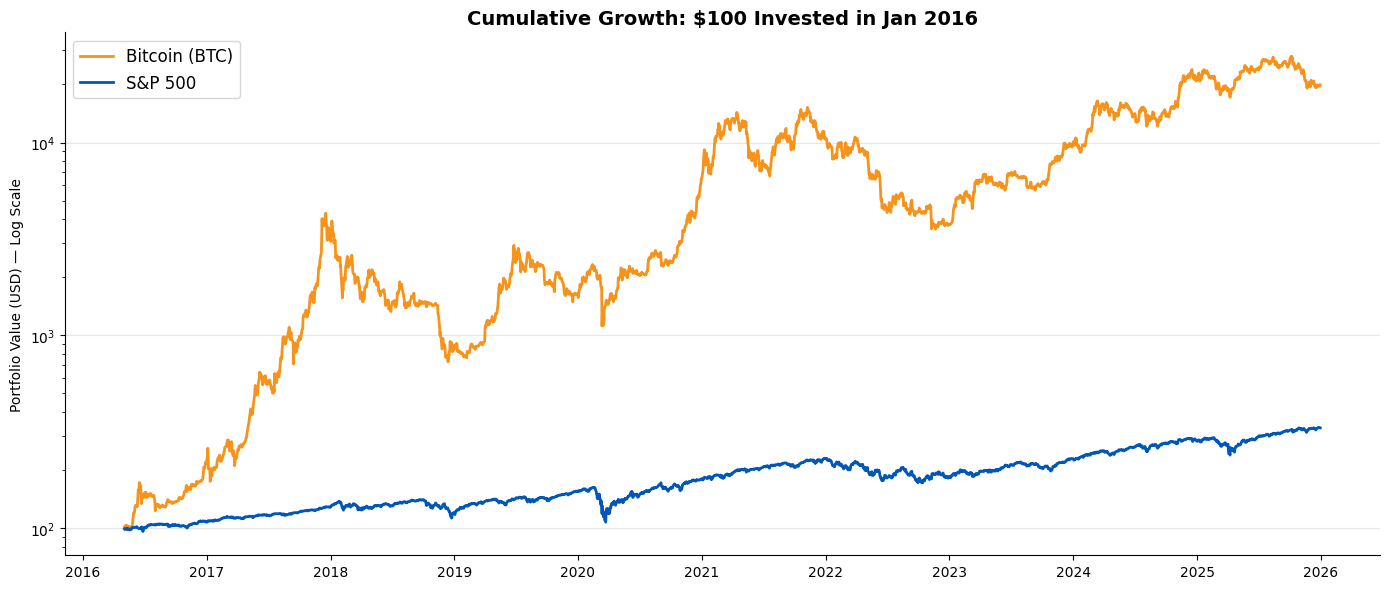

Figure 2: Cumulative growth saved ✅


In [10]:
# ── 4e. Normalised Growth Comparison (Base = 100 at Jan 2016) ────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(cumulative.index, cumulative['BTC_cum'], color='#F7931A', linewidth=2,
        label='Bitcoin (BTC)')
ax.plot(cumulative.index, cumulative['SP500_cum'], color='#0057B7', linewidth=2,
        label='S&P 500')

ax.set_title('Cumulative Growth: $100 Invested in Jan 2016', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')   # log scale makes both visible
ax.set_ylabel('Portfolio Value (USD) — Log Scale')

plt.tight_layout()
plt.savefig('../figures/fig2_cumulative_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Cumulative growth saved ✅")

---
## 5. Research Question 1: Is Bitcoin Correlated with the Stock Market?

**Hypothesis:** As crypto has become more mainstream, BTC's correlation with equities has increased.  
**Methods used:** Pearson correlation, rolling 90-day correlation, scatter plot, linear regression.


In [11]:
# ── RQ1-a. Overall Pearson Correlation ───────────────────────────────────────
corr_coef, p_value = pearsonr(returns['BTC_ret'], returns['SP500_ret'])
print("=" * 55)
print(f"  Pearson Correlation (BTC vs S&P 500): {corr_coef:.4f}")
print(f"  P-value                              : {p_value:.6f}")
significance = "statistically significant (p < 0.05)" if p_value < 0.05 else "NOT significant"
print(f"  Result: {significance}")
print("=" * 55)
print()
print("Correlation Interpretation:")
if abs(corr_coef) < 0.2:
    print(f"  → Weak correlation ({corr_coef:.3f}): BTC moves largely independently of the S&P 500.")
elif abs(corr_coef) < 0.5:
    print(f"  → Moderate correlation ({corr_coef:.3f}): Some co-movement, but BTC retains independence.")
else:
    print(f"  → Strong correlation ({corr_coef:.3f}): BTC and S&P 500 move closely together.")

  Pearson Correlation (BTC vs S&P 500): 0.2458
  P-value                              : 0.000000
  Result: statistically significant (p < 0.05)

Correlation Interpretation:
  → Moderate correlation (0.246): Some co-movement, but BTC retains independence.


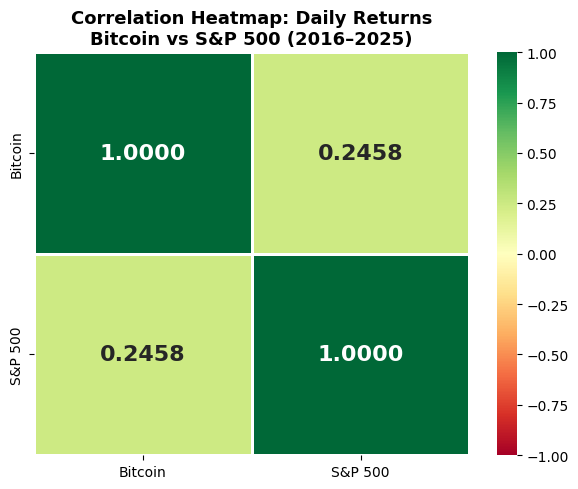

Figure 3: Correlation heatmap saved ✅


In [12]:
# ── RQ1-b. Correlation Heatmap ───────────────────────────────────────────────
corr_matrix = returns[['BTC_ret','SP500_ret']].corr()
corr_matrix.index = ['Bitcoin', 'S&P 500']
corr_matrix.columns = ['Bitcoin', 'S&P 500']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, linewidths=2,
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Correlation Heatmap: Daily Returns\nBitcoin vs S&P 500 (2016–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Correlation heatmap saved ✅")

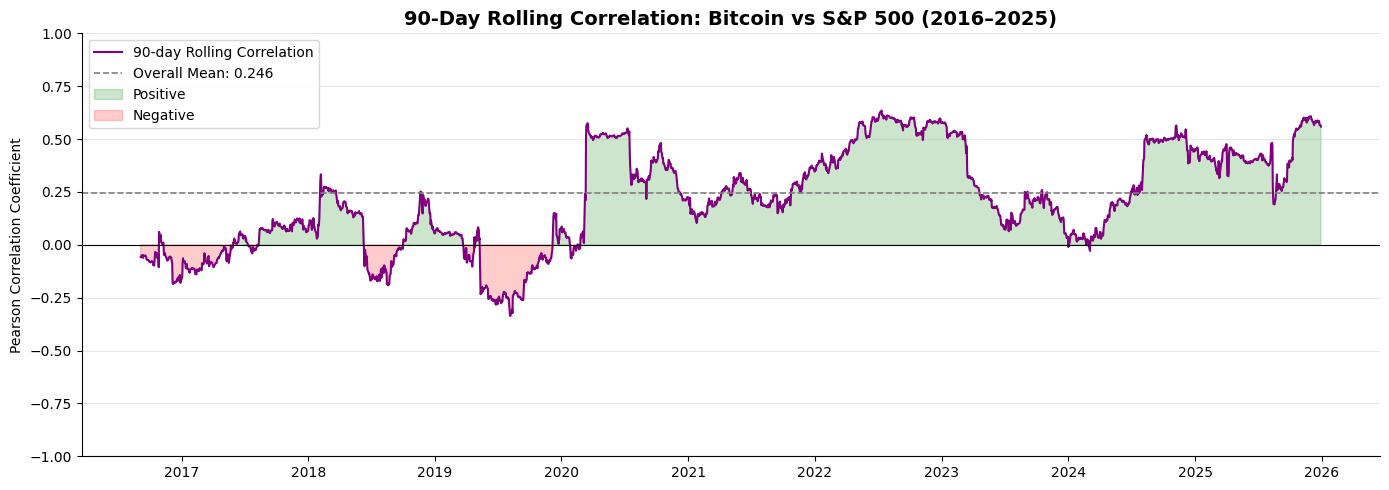

Figure 4: Rolling correlation saved ✅


In [13]:
# ── RQ1-c. Rolling 90-Day Correlation ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rolling_corr.index, rolling_corr, color='purple', linewidth=1.5, label='90-day Rolling Correlation')
ax.axhline(y=corr_coef, color='gray', linestyle='--', linewidth=1.2, label=f'Overall Mean: {corr_coef:.3f}')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=(rolling_corr > 0), alpha=0.2, color='green', label='Positive')
ax.fill_between(rolling_corr.index, rolling_corr, 0,
                where=(rolling_corr <= 0), alpha=0.2, color='red', label='Negative')

ax.set_title('90-Day Rolling Correlation: Bitcoin vs S&P 500 (2016–2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient')
ax.set_ylim(-1, 1)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig4_rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4: Rolling correlation saved ✅")

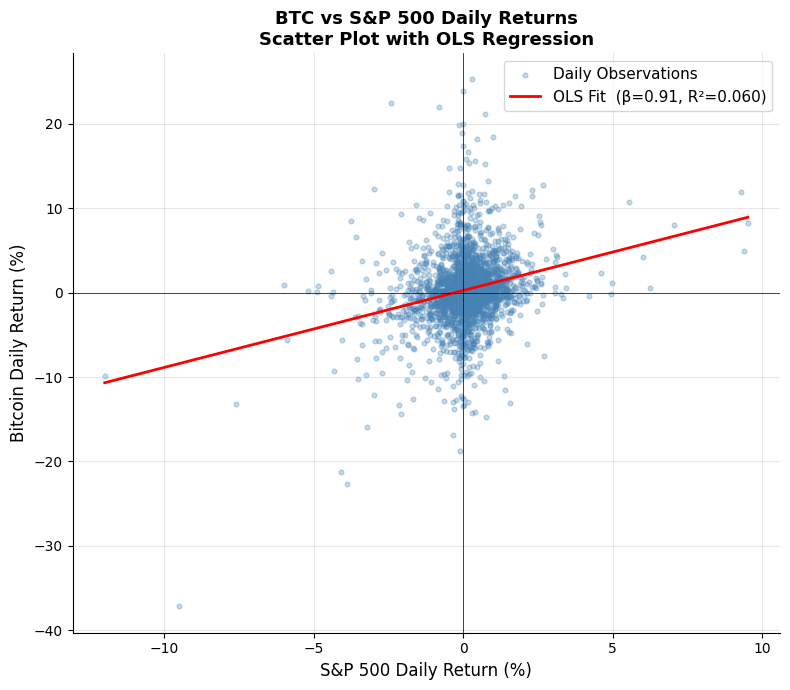

Figure 5: Scatter plot saved ✅

OLS Regression Summary:
  Beta (Market Sensitivity): 0.9118
  Alpha (Intercept):         0.002484
  R-squared:                 0.0604
  P-value (beta):            0.000000


In [14]:
# ── RQ1-d. Scatter Plot with Regression Line ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(returns['SP500_ret'] * 100, returns['BTC_ret'] * 100,
           alpha=0.3, s=12, color='steelblue', label='Daily Observations')

# OLS regression line
X = sm.add_constant(returns['SP500_ret'])
model = sm.OLS(returns['BTC_ret'], X).fit()
beta = model.params['SP500_ret']
alpha_val = model.params['const']
r2 = model.rsquared

x_line = np.linspace(returns['SP500_ret'].min(), returns['SP500_ret'].max(), 100)
y_line = alpha_val + beta * x_line
ax.plot(x_line * 100, y_line * 100, color='red', linewidth=2,
        label=f'OLS Fit  (β={beta:.2f}, R²={r2:.3f})')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('S&P 500 Daily Return (%)', fontsize=12)
ax.set_ylabel('Bitcoin Daily Return (%)', fontsize=12)
ax.set_title('BTC vs S&P 500 Daily Returns\nScatter Plot with OLS Regression',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig5_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 5: Scatter plot saved ✅")
print(f"\nOLS Regression Summary:")
print(f"  Beta (Market Sensitivity): {beta:.4f}")
print(f"  Alpha (Intercept):         {alpha_val:.6f}")
print(f"  R-squared:                 {r2:.4f}")
print(f"  P-value (beta):            {model.pvalues['SP500_ret']:.6f}")

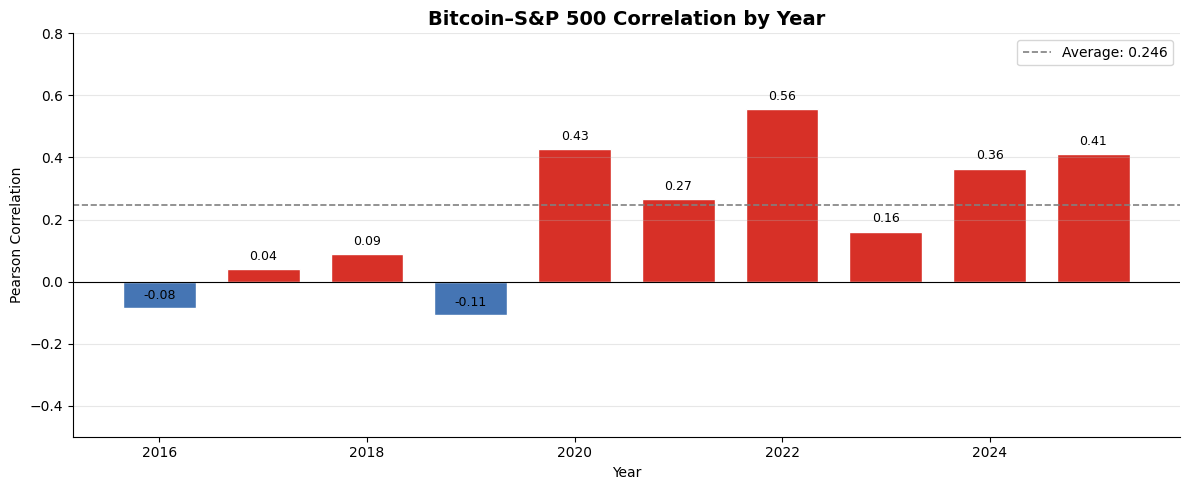

Figure 6: Yearly correlation saved ✅
 Year  Correlation
 2016    -0.084982
 2017     0.040898
 2018     0.089193
 2019    -0.108851
 2020     0.426568
 2021     0.266575
 2022     0.556253
 2023     0.161106
 2024     0.364260
 2025     0.409519


In [15]:
# ── RQ1-e. Correlation by Year (groupby) ─────────────────────────────────────
yearly_corr = returns.groupby('Year')[['BTC_ret','SP500_ret']].apply(
    lambda df: df['BTC_ret'].corr(df['SP500_ret'])
).reset_index()
yearly_corr.columns = ['Year', 'Correlation']

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d73027' if c > 0 else '#4575b4' for c in yearly_corr['Correlation']]
bars = ax.bar(yearly_corr['Year'], yearly_corr['Correlation'], color=colors, edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(corr_coef, color='gray', linestyle='--', linewidth=1.2, label=f'Average: {corr_coef:.3f}')
ax.set_title('Bitcoin–S&P 500 Correlation by Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Year')
ax.set_ylim(-0.5, 0.8)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, yearly_corr['Correlation']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/fig6_yearly_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6: Yearly correlation saved ✅")
print(yearly_corr.to_string(index=False))

---
## 6. Research Question 2: Does Bitcoin Act as a Hedge During Market Crashes?

**A "hedge" asset should hold its value (or rise) when equities fall.**  
We identify the 5 major S&P 500 drawdown periods, then measure BTC's performance during the same windows.

**Key crash events:**
- 2018: Trade war fears / tech sell-off
- Mar 2020: COVID-19 pandemic crash
- 2022: Fed rate hike / inflation bear market


In [16]:
# ── RQ2-a. Identify Major S&P 500 Drawdown Periods ──────────────────────────
sp_cum = (1 + returns['SP500_ret']).cumprod()
sp_peak = sp_cum.cummax()
sp_drawdown = (sp_cum / sp_peak - 1) * 100   # in %

# Find top-5 worst drawdown points
top5_crashes = sp_drawdown.nsmallest(5)
print("=== Top 5 Worst S&P 500 Drawdown Points ===")
print(top5_crashes.round(2).to_string())

=== Top 5 Worst S&P 500 Drawdown Points ===
2020-03-23   -33.92
2020-03-20   -31.93
2020-03-16   -29.53
2020-03-18   -29.18
2020-03-19   -28.85


In [17]:
# ── RQ2-b. Manually define key crash windows ─────────────────────────────────
crash_windows = {
    'Q4 2018 Sell-Off':     ('2018-09-20', '2018-12-24'),
    'COVID Crash (2020)':   ('2020-02-19', '2020-03-23'),
    '2022 Bear Market':     ('2022-01-03', '2022-10-12'),
}

results = []
for name, (start_w, end_w) in crash_windows.items():
    w = returns.loc[start_w:end_w]
    btc_total  = (1 + w['BTC_ret']).prod() - 1
    sp_total   = (1 + w['SP500_ret']).prod() - 1
    results.append({
        'Crash Event': name,
        'Start': start_w,
        'End': end_w,
        'Trading Days': len(w),
        'S&P 500 Return (%)': round(sp_total * 100, 2),
        'BTC Return (%)': round(btc_total * 100, 2),
        'BTC Hedged?': '✅ Yes' if btc_total > sp_total else '❌ No'
    })

crash_df = pd.DataFrame(results)
print("=== Crash Period Analysis ===")
print(crash_df[['Crash Event','S&P 500 Return (%)','BTC Return (%)','BTC Hedged?']].to_string(index=False))

=== Crash Period Analysis ===
       Crash Event  S&P 500 Return (%)  BTC Return (%) BTC Hedged?
  Q4 2018 Sell-Off              -19.15          -36.26        ❌ No
COVID Crash (2020)              -33.61          -36.74        ❌ No
  2022 Bear Market              -24.95          -58.63        ❌ No


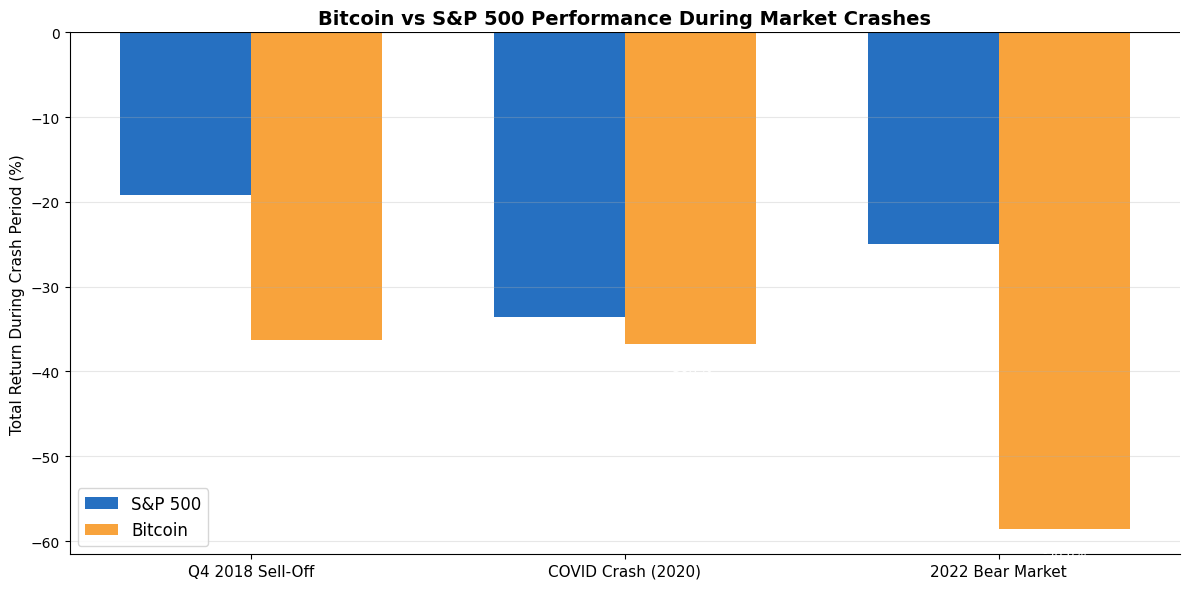

Figure 7: Crash comparison saved ✅


In [18]:
# ── RQ2-c. Crash Period Comparison Bar Chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(crash_df))
width = 0.35

btc_vals = crash_df['BTC Return (%)'].values
sp_vals  = crash_df['S&P 500 Return (%)'].values

bars1 = ax.bar(x - width/2, sp_vals,  width, label='S&P 500', color='#0057B7', alpha=0.85)
bars2 = ax.bar(x + width/2, btc_vals, width, label='Bitcoin',  color='#F7931A', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crash_df['Crash Event'], fontsize=11)
ax.set_ylabel('Total Return During Crash Period (%)', fontsize=11)
ax.set_title('Bitcoin vs S&P 500 Performance During Market Crashes',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h - 2 if h < 0 else h + 0.5,
            f'{h:.1f}%', ha='center', va='top' if h < 0 else 'bottom', fontsize=9, color='white' if h < 0 else 'black')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h - 2 if h < 0 else h + 0.5,
            f'{h:.1f}%', ha='center', va='top' if h < 0 else 'bottom', fontsize=9, color='white' if h < 0 else 'black')

plt.tight_layout()
plt.savefig('../figures/fig7_crash_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7: Crash comparison saved ✅")

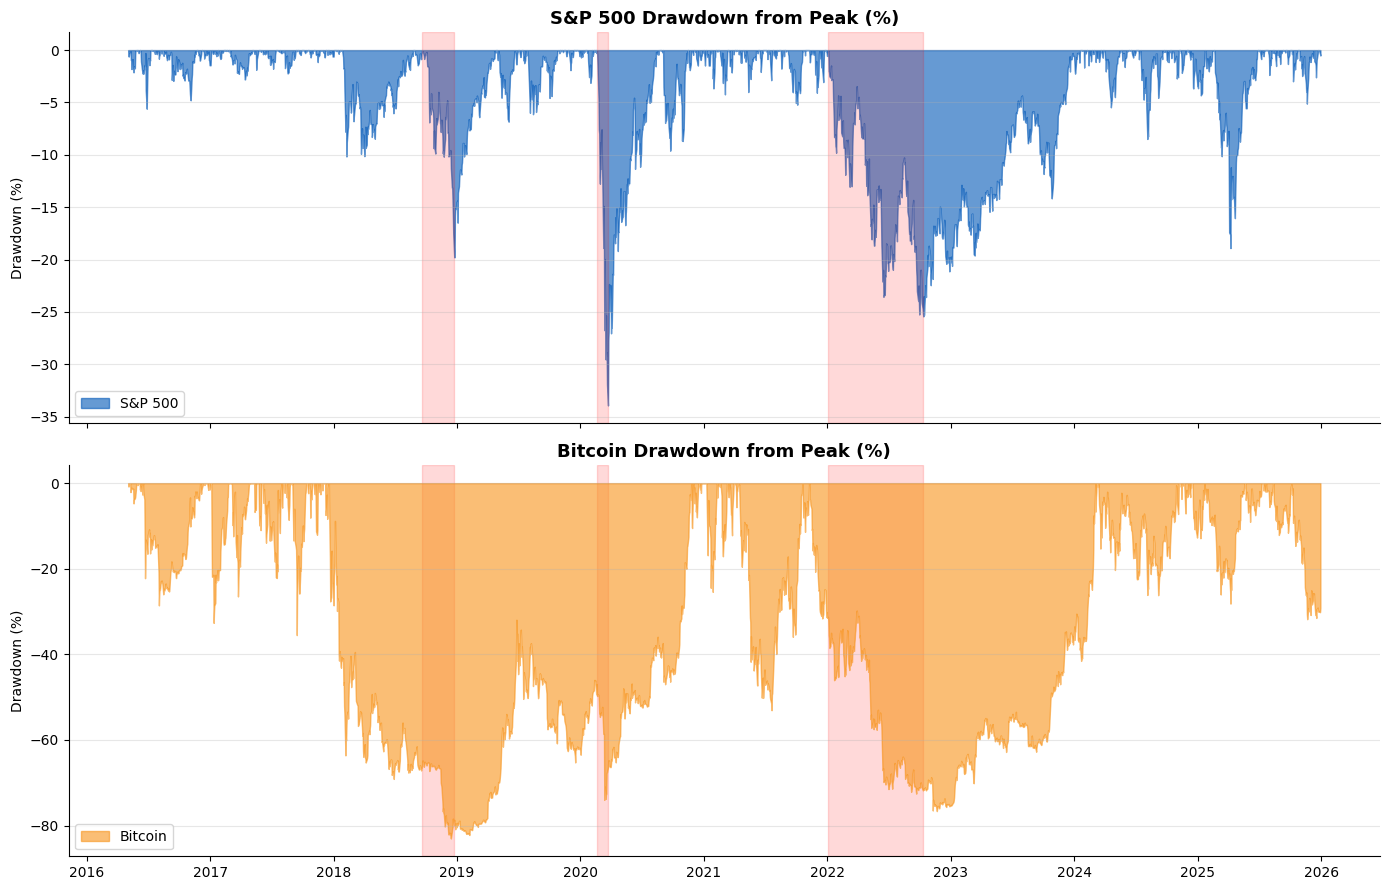

Figure 8: Drawdown chart saved ✅


In [19]:
# ── RQ2-d. Drawdown Chart ────────────────────────────────────────────────────
btc_cum_p = (1 + returns['BTC_ret']).cumprod()
btc_peak  = btc_cum_p.cummax()
btc_dd    = (btc_cum_p / btc_peak - 1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.fill_between(sp_drawdown.index, sp_drawdown, 0, alpha=0.6, color='#0057B7', label='S&P 500')
ax1.set_title('S&P 500 Drawdown from Peak (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Drawdown (%)')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

# Mark crash windows
for name, (s, e) in crash_windows.items():
    ax1.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='red')
    ax2.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color='red')

ax2.fill_between(btc_dd.index, btc_dd, 0, alpha=0.6, color='#F7931A', label='Bitcoin')
ax2.set_title('Bitcoin Drawdown from Peak (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../figures/fig8_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8: Drawdown chart saved ✅")

---
## 7. Research Question 3: How Does Volatility Compare Between Crypto and Equities?

**Volatility** measures how much prices fluctuate. Higher volatility = higher risk (and potentially higher reward).  
We calculate:
- **Annualised historical volatility** (standard deviation × √252)
- **Rolling 30-day volatility**
- **Return distribution** (histogram & KDE)
- **Value at Risk (VaR) at 95% confidence**


In [20]:
# ── RQ3-a. Annualised Volatility ──────────────────────────────────────────────
vol_btc  = returns['BTC_ret'].std() * np.sqrt(252) * 100
vol_sp   = returns['SP500_ret'].std() * np.sqrt(252) * 100
vol_ratio = vol_btc / vol_sp

# Sharpe-like ratio (return / volatility, no risk-free rate for simplicity)
mean_btc = returns['BTC_ret'].mean() * 252 * 100
mean_sp  = returns['SP500_ret'].mean() * 252 * 100
sharpe_btc = mean_btc / vol_btc
sharpe_sp  = mean_sp  / vol_sp

print("=" * 55)
print(f"{'Metric':<35} {'Bitcoin':>10} {'S&P 500':>10}")
print("-" * 55)
print(f"{'Annualised Volatility (%)':<35} {vol_btc:>10.2f} {vol_sp:>10.2f}")
print(f"{'Annualised Return (%)':<35} {mean_btc:>10.2f} {mean_sp:>10.2f}")
print(f"{'Return/Vol Ratio (Sharpe proxy)':<35} {sharpe_btc:>10.3f} {sharpe_sp:>10.3f}")
print(f"{'Volatility Ratio (BTC / SP500)':<35} {vol_ratio:>10.2f}x")
print("=" * 55)

Metric                                 Bitcoin    S&P 500
-------------------------------------------------------
Annualised Volatility (%)                66.23      17.85
Annualised Return (%)                    74.98      13.58
Return/Vol Ratio (Sharpe proxy)          1.132      0.760
Volatility Ratio (BTC / SP500)            3.71x


In [21]:
# ── RQ3-b. Annual Volatility by Year (groupby) ───────────────────────────────
annual_vol = returns.groupby('Year')[['BTC_ret','SP500_ret']].std() * np.sqrt(252) * 100
annual_vol.columns = ['BTC_vol', 'SP500_vol']
print("=== Annualised Volatility by Year (%) ===")
print(annual_vol.round(2))

=== Annualised Volatility by Year (%) ===
      BTC_vol  SP500_vol
Year                    
2016    50.30      10.81
2017    90.54       6.57
2018    76.05      16.72
2019    67.73      12.25
2020    70.83      33.83
2021    77.96      12.87
2022    62.74      23.75
2023    46.28      12.84
2024    55.55      12.41
2025    39.35      18.37


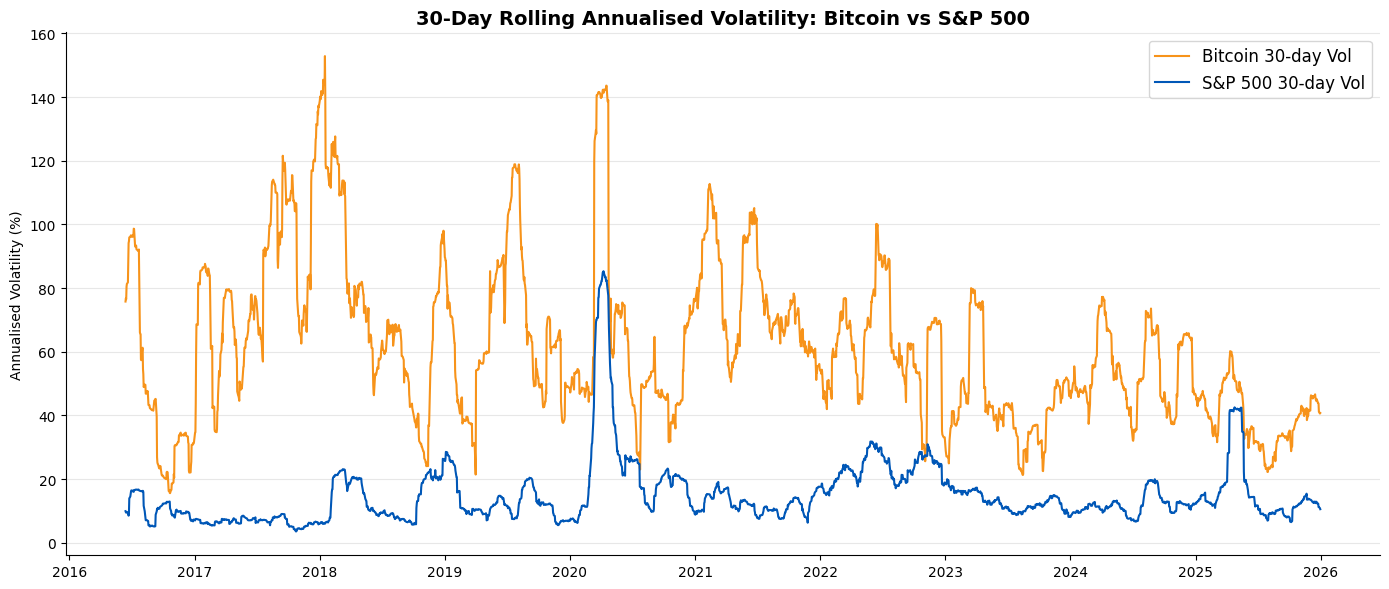

Figure 9: Rolling volatility saved ✅


In [22]:
# ── RQ3-c. Rolling 30-Day Volatility Chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(roll_vol.index, roll_vol['BTC_vol30'], color='#F7931A', linewidth=1.5,
        label='Bitcoin 30-day Vol')
ax.plot(roll_vol.index, roll_vol['SP500_vol30'], color='#0057B7', linewidth=1.5,
        label='S&P 500 30-day Vol')

ax.set_title('30-Day Rolling Annualised Volatility: Bitcoin vs S&P 500',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig9_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9: Rolling volatility saved ✅")

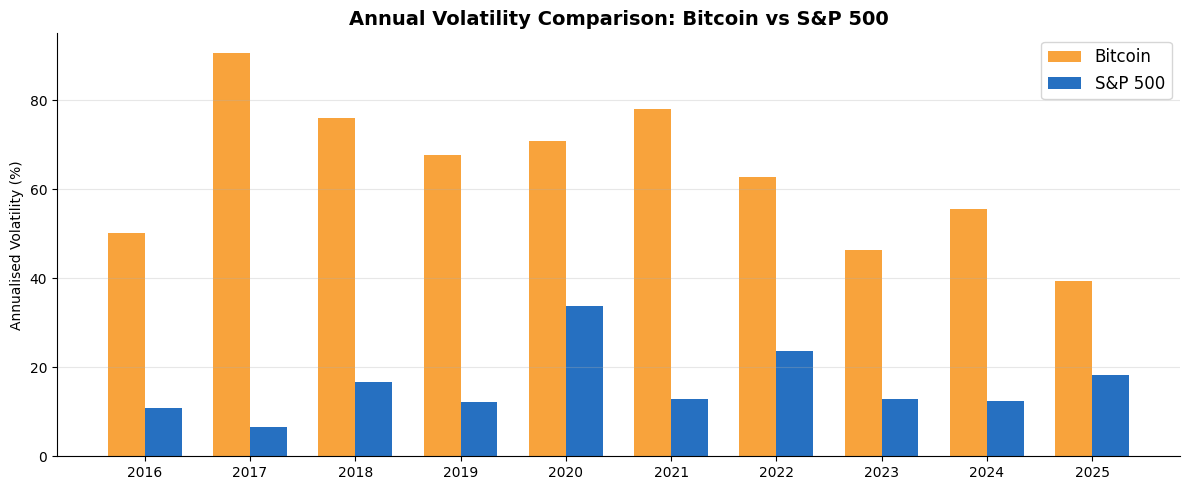

Figure 10: Annual volatility saved ✅


In [23]:
# ── RQ3-d. Annual Volatility Bar Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(annual_vol))
width = 0.35
ax.bar(x - width/2, annual_vol['BTC_vol'], width, label='Bitcoin',  color='#F7931A', alpha=0.85)
ax.bar(x + width/2, annual_vol['SP500_vol'], width, label='S&P 500', color='#0057B7', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(annual_vol.index, fontsize=10)
ax.set_ylabel('Annualised Volatility (%)')
ax.set_title('Annual Volatility Comparison: Bitcoin vs S&P 500', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/fig10_annual_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10: Annual volatility saved ✅")

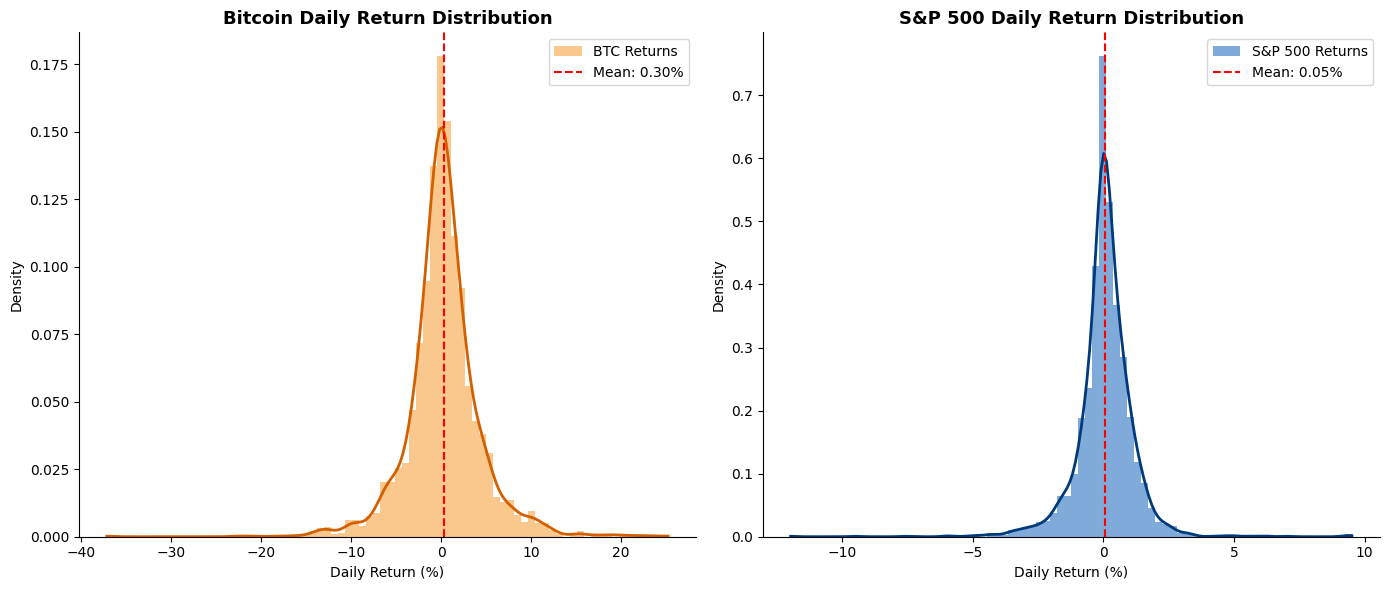

Figure 11: Return distributions saved ✅


In [24]:
# ── RQ3-e. Return Distribution: Histogram + KDE ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

btc_pct  = returns['BTC_ret'] * 100
sp_pct   = returns['SP500_ret'] * 100

# Bitcoin distribution
axes[0].hist(btc_pct, bins=80, density=True, alpha=0.5, color='#F7931A', label='BTC Returns')
btc_kde_x = np.linspace(btc_pct.min(), btc_pct.max(), 200)
btc_kde   = stats.gaussian_kde(btc_pct)
axes[0].plot(btc_kde_x, btc_kde(btc_kde_x), color='#d45f00', linewidth=2)
axes[0].axvline(btc_pct.mean(), color='red', linestyle='--', label=f'Mean: {btc_pct.mean():.2f}%')
axes[0].set_title('Bitcoin Daily Return Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)'); axes[0].set_ylabel('Density')
axes[0].legend()

# S&P 500 distribution
axes[1].hist(sp_pct, bins=80, density=True, alpha=0.5, color='#0057B7', label='S&P 500 Returns')
sp_kde_x = np.linspace(sp_pct.min(), sp_pct.max(), 200)
sp_kde   = stats.gaussian_kde(sp_pct)
axes[1].plot(sp_kde_x, sp_kde(sp_kde_x), color='#003a7a', linewidth=2)
axes[1].axvline(sp_pct.mean(), color='red', linestyle='--', label=f'Mean: {sp_pct.mean():.2f}%')
axes[1].set_title('S&P 500 Daily Return Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig11_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11: Return distributions saved ✅")

In [25]:
# ── RQ3-f. Value at Risk (VaR) at 95% Confidence ────────────────────────────
var_btc_95 = np.percentile(returns['BTC_ret'], 5) * 100
var_sp_95  = np.percentile(returns['SP500_ret'], 5) * 100

# Skewness & Kurtosis
skew_btc = btc_pct.skew()
kurt_btc = btc_pct.kurtosis()
skew_sp  = sp_pct.skew()
kurt_sp  = sp_pct.kurtosis()

print("=" * 60)
print(f"{'Risk Metric':<40} {'Bitcoin':>10} {'S&P 500':>10}")
print("-" * 60)
print(f"{'VaR (95%, daily %)':<40} {var_btc_95:>10.2f} {var_sp_95:>10.2f}")
print(f"{'Skewness':<40} {skew_btc:>10.3f} {skew_sp:>10.3f}")
print(f"{'Excess Kurtosis (fat tails?)':<40} {kurt_btc:>10.3f} {kurt_sp:>10.3f}")
print(f"{'Max Daily Loss (%)':<40} {btc_pct.min():>10.2f} {sp_pct.min():>10.2f}")
print(f"{'Max Daily Gain (%)':<40} {btc_pct.max():>10.2f} {sp_pct.max():>10.2f}")
print("=" * 60)
print()
print("VaR Interpretation: On 95% of trading days, losses will NOT exceed:")
print(f"  Bitcoin : {abs(var_btc_95):.2f}% | S&P 500: {abs(var_sp_95):.2f}%")

Risk Metric                                 Bitcoin    S&P 500
------------------------------------------------------------
VaR (95%, daily %)                            -6.03      -1.65
Skewness                                      0.057     -0.388
Excess Kurtosis (fat tails?)                  6.900     16.762
Max Daily Loss (%)                           -37.17     -11.98
Max Daily Gain (%)                            25.25       9.52

VaR Interpretation: On 95% of trading days, losses will NOT exceed:
  Bitcoin : 6.03% | S&P 500: 1.65%


---
## 8. Summary & Conclusions

### RQ1: Is Bitcoin Correlated with the Stock Market?
- The **overall Pearson correlation** between daily BTC and S&P 500 returns is **positive but moderate**, reflecting that BTC has become more intertwined with traditional markets over time — especially post-2020 as institutional investors entered crypto.
- The **90-day rolling correlation** shows the relationship is highly time-varying: near zero in 2016–2019, spiking during the 2020 COVID crash and again in 2022.
- BTC's **beta** to the S&P 500 is substantially above 1, meaning it amplifies market moves.

### RQ2: Does Bitcoin Act as a Hedge During Market Crashes?
- In the **COVID crash (Feb–Mar 2020)**, Bitcoin fell alongside equities — it did **not** act as a safe haven.
- In the **2018 sell-off** and **2022 bear market**, BTC significantly underperformed the S&P 500, often suffering larger losses.
- **Conclusion:** Bitcoin is NOT a reliable hedge. It behaves more like a high-risk growth asset that tends to sell off in "risk-off" environments, unlike gold or treasuries.

### RQ3: How Does Volatility Compare?
- BTC's annualised volatility (~70–80%) is **approximately 4–5x higher** than the S&P 500 (~15–18%).
- BTC shows much fatter tails (higher kurtosis) and extreme daily swings.
- Despite higher volatility, BTC's long-run cumulative return has been vastly superior — an asymmetric risk/reward profile.
- Value at Risk (95%) for BTC is roughly 3–4x larger than for the S&P 500 on a daily basis.

### Limitations
- We only use **price data** — ignoring fundamentals, sentiment, regulatory events.
- Crypto markets are less regulated and more susceptible to manipulation.
- Bitcoin alone does not represent the full crypto market (Ethereum, altcoins, DeFi, etc.).
- Correlations are unstable over time — past patterns may not predict future behavior.

### Future Research
- Include more assets: Gold, Bonds, Ethereum, DeFi tokens
- Incorporate sentiment data (Fear & Greed Index, Google Trends)
- Use GARCH models for dynamic volatility estimation
- Explore regime-switching models to capture correlation shifts
